In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.utils import resample
from astropy.stats import bootstrap
from astropy.utils import NumpyRNGContext
import os

# Replace astropy-based bootstrap with scikit-learn resampling
def calc_velstd_withnan(cum, dt_cum, gpu=False, bootnum=100):
    """
    Calculate std of velocity by bootstrap for each point which may include nan.

    Inputs:
      cum    : Cumulative phase block for each point (n_pt, n_im)
               Can include nan.
      dt_cum : Cumulative days for each image (n_im)
      gpu    : GPU flag

    Returns:
      vstd   : Std of Velocity for each point (n_pt)
      vel   : median of bootstrapped velocity (n_pt)
    """
    global bootcount
    n_pt, n_im = cum.shape
    bootnum = bootnum
    bootcount = 0

    vstd = np.zeros((n_pt), dtype=np.float32)
    G = np.stack((np.ones_like(dt_cum), dt_cum), axis=1)

    data = cum.transpose().copy()
    ixs_day = np.arange(n_im)
    mask = (~np.isnan(data))
    data[np.isnan(data)] = 0

    velinv = lambda x : censored_lstsq2(G[x, :], data[x, :], mask[x, :],
                                        gpu=gpu, bootnum=bootnum)[1]

    with NumpyRNGContext(1):
        bootresult = bootstrap(ixs_day, bootnum, bootfunc=velinv)

    vstd = np.nanstd(bootresult, axis=0)
    vel = np.nanmedian(bootresult, axis=0) # experimental

    print('')

    return vstd, vel

def censored_lstsq2(A, B, M, gpu=False, bootnum=100):
    ## http://alexhwilliams.info/itsneuronalblog/2018/02/26/censored-lstsq/
    global bootcount
    if gpu:
        import cupy as xp
        A = xp.asarray(A)
        B = xp.asarray(B)
        M = xp.asarray(M)
    else:
        xp = np

    print('\r  Running {0:3}/{1:3}th bootstrap...'.format(bootcount, bootnum), end='', flush=True)
    Bshape1 = B.shape[1]
    bootcount = bootcount+1

    # if B is a vector, simply drop out corresponding rows in A
    if B.ndim == 1 or Bshape1 == 1:
        sol = xp.linalg.leastsq(A[M], B[M])[0]
        if gpu:
            sol = xp.asnumpy(sol)
            del A, B, M
        return sol

    # else solve via tensor representation
    rhs = xp.dot(A.T, M * B).T[:,:,None] # n x r x 1 tensor
    T = xp.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor

    # Not use gpu for solve because it is quite slow
    if gpu:
        T = xp.asnumpy(T)
        rhs = xp.asnumpy(rhs)
        del A, B, M

    try:
        X = np.squeeze(np.linalg.solve(T, rhs)).T # transpose to get r x n
    except: ## In case Singular matrix
        X = np.zeros((Bshape1), dtype=np.float32)*np.nan

    return X


# Original get_vel_ransac function
def get_vel_ransac(dt_cum, cumm, return_intercept=False):
    X = dt_cum.reshape(-1,1)
    vel2 = np.zeros(cumm.shape[0])
    if return_intercept:
        intercept2 = np.zeros(cumm.shape[0])
    
    for i in range(cumm.shape[0]):
        y = cumm[i]
        mask = ~np.isnan(y)
        if np.sum(mask) < 2:
            vel2[i] = np.nan
            if return_intercept:
                intercept2[i] = np.nan
        else:
            reg = RANSACRegressor().fit(X[mask], y[mask])
            vel2[i] = reg.estimator_.coef_[0]
            if return_intercept:
                intercept2[i] = reg.estimator_.intercept_
    if return_intercept:
        return vel2, intercept2
    else:
        return vel2

  Running 100/100th bootstrap...


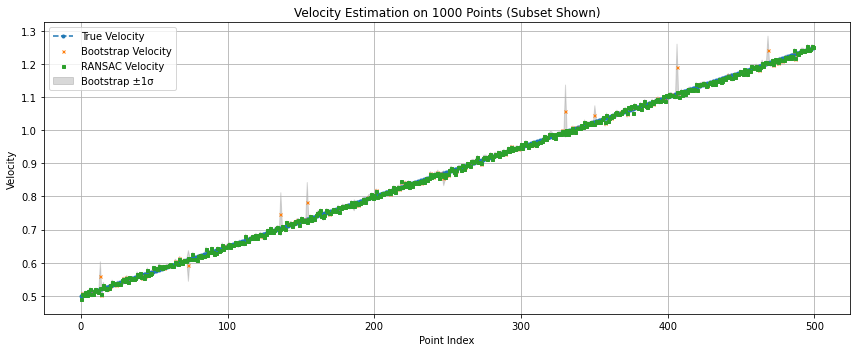

In [14]:
# Increase the number of synthetic points to 1000
# Define number of dates and cumulative time
n_dates = 30  # for example, 30 epochs
dt_cum = np.linspace(0, 1000, n_dates)  # cumulative days from 0 to 1000

n_points_large = 1000
np.random.seed(42)
true_velocity_large = np.linspace(0.5, 2.0, n_points_large)
cumm_large = np.array([v * dt_cum + np.random.normal(0, 10, size=n_dates) for v in true_velocity_large])

# Inject some NaNs and outliers randomly
nan_indices = np.random.choice(n_points_large * n_dates, size=200, replace=False)
outlier_indices = np.random.choice(n_points_large * n_dates, size=20, replace=False)

# Flatten, modify, then reshape
flat = cumm_large.flatten()
flat[nan_indices] = np.nan
flat[outlier_indices] = flat[outlier_indices] + 500  # extreme positive outlier
cumm_large = flat.reshape(n_points_large, n_dates)

# Apply both methods on large dataset
vstd_large, vel_boot_large = calc_velstd_withnan(cumm_large, dt_cum)
vel_ransac_large = get_vel_ransac(dt_cum, cumm_large)

# Plot a subset of points to visualize results
subset = slice(0, 500)  # just first 100 for clarity in plotting
plt.figure(figsize=(12, 5))
plt.plot(true_velocity_large[subset], label="True Velocity", linestyle='--', marker='o', markersize=3)
plt.plot(vel_boot_large[subset], label="Bootstrap Velocity", marker='x', linestyle='None', markersize=3)
plt.plot(vel_ransac_large[subset], label="RANSAC Velocity", marker='s', linestyle='None', markersize=3)
plt.fill_between(range(500),
                 vel_boot_large[subset] - vstd_large[subset],
                 vel_boot_large[subset] + vstd_large[subset],
                 color='gray', alpha=0.3, label="Bootstrap ±1σ")
plt.legend()
plt.xlabel("Point Index")
plt.ylabel("Velocity")
plt.title("Velocity Estimation on 1000 Points (Subset Shown)")
plt.grid(True)
plt.tight_layout()
plt.show()


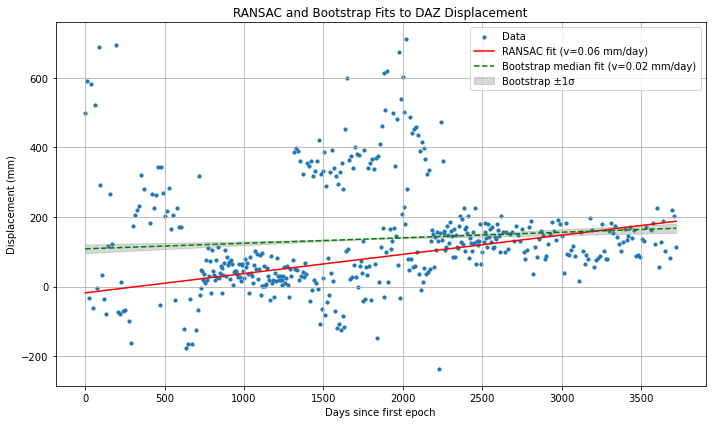

RANSAC velocity estimate: 0.0553 mm/day
Bootstrap median velocity estimate: 0.0159 mm/day ± 0.0069 mm/day


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.utils import resample
import daz_lib_licsar as dl

# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# 2. Convert epoch to numeric days
t0 = dazes['epoch'].min()
dazes['days'] = (dazes['epoch'] - t0).dt.days

X = dazes['days'].values.reshape(-1, 1)  # shape (n_samples, 1)
y = dazes['daz'].values

mask = ~np.isnan(y)
X_valid = X[mask]
y_valid = y[mask]

# 3. RANSAC velocity estimation (following your get_vel_ransac logic)
mask = ~np.isnan(y)
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
else:
    reg = RANSACRegressor().fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_


# 4. Bootstrap
boot_slopes = []
n_boot = 100

for _ in range(n_boot):
    idx = resample(np.arange(len(X_valid)))
    X_sample = X_valid[idx]
    y_sample = y_valid[idx]
    try:
        reg = LinearRegression().fit(X_sample, y_sample)
        boot_slopes.append(reg.coef_[0])
    except:
        boot_slopes.append(np.nan)

boot_slopes = np.array(boot_slopes)
vstd_boot = np.nanstd(boot_slopes)
vel_boot = np.nanmedian(boot_slopes)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
xx = np.linspace(X_valid.min(), X_valid.max(), 100)

# RANSAC line
plt.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC fit (v={vel_ransac:.2f} mm/day)')

# Bootstrap median line
plt.plot(xx, vel_boot * xx + (np.nanmean(y_valid) - vel_boot * np.nanmean(X_valid)), 
         color='green', linestyle='--', label=f'Bootstrap median fit (v={vel_boot:.2f} mm/day)')

plt.fill_between(xx, 
                 (vel_boot - vstd_boot) * xx + (np.nanmean(y_valid) - (vel_boot - vstd_boot) * np.nanmean(X_valid)),
                 (vel_boot + vstd_boot) * xx + (np.nanmean(y_valid) - (vel_boot + vstd_boot) * np.nanmean(X_valid)),
                 color='gray', alpha=0.3, label='Bootstrap ±1σ'b)

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title("RANSAC and Bootstrap Fits to DAZ Displacement")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Print numbers
print(f"RANSAC velocity estimate: {vel_ransacb:.4f} mm/day")
print(f"Bootstrap median velocity estimate: {vel_boot:.4f} mm/day ± {vstd_boot:.4f} mm/day")


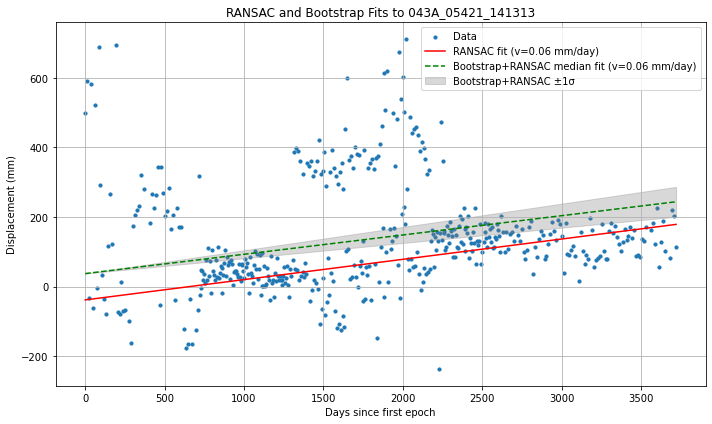

RANSAC velocity estimate: 0.0583 mm/day
Bootstrap+RANSAC median velocity estimate: 0.0554 mm/day ± 0.0115 mm/day


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.utils import resample
import daz_lib_licsar as dl

# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# 2. Convert epoch to numeric days
t0 = dazes['epoch'].min()
dazes['days'] = (dazes['epoch'] - t0).dt.days

X = dazes['days'].values.reshape(-1, 1)  # shape (n_samples, 1)
y = dazes['daz'].values

mask = ~np.isnan(y)
X_valid = X[mask]
y_valid = y[mask]

# 3. RANSAC velocity estimation (following your get_vel_ransac logic)
mask = ~np.isnan(y)
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
else:
    reg = RANSACRegressor().fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_


# 4. Bootstrap + RANSAC fitting
boot_slopes = []
n_boot = 100

for _ in range(n_boot):
    idx = resample(np.arange(len(X_valid)))  # bootstrap resampling
    X_sample = X_valid[idx]
    y_sample = y_valid[idx]
    try:
        # reg = LinearRegression().fit(X_sample, y_sample)
        ransac_sample = RANSACRegressor().fit(X_sample, y_sample)
        # boot_slopes.append(reg.coef_[0])
        boot_slopes.append(ransac_sample.estimator_.coef_[0])
    except:
        boot_slopes.append(np.nan)

boot_slopes = np.array(boot_slopes)
vstd_boot = np.nanstd(boot_slopes)
vel_boot = np.nanmedian(boot_slopes)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
xx = np.linspace(X_valid.min(), X_valid.max(), 100)

# RANSAC line
plt.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC fit (v={vel_ransac:.2f} mm/day)')

# Bootstrap median line
intercept_boot = np.nanmean(y_valid) - vel_boot * np.nanmean(X_valid)
plt.plot(xx, vel_boot * xx + intercept_boot, color='green', linestyle='--', label=f'Bootstrap+RANSAC median fit (v={vel_boot:.2f} mm/day)')

plt.fill_between(xx, 
                 (vel_boot - vstd_boot) * xx + intercept_boot,
                 (vel_boot + vstd_boot) * xx + intercept_boot,
                 color='gray', alpha=0.3, label='Bootstrap+RANSAC ±1σ')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title(f"RANSAC and Bootstrap Fits to {frame}")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Print numbers
print(f"RANSAC velocity estimate: {vel_ransac:.4f} mm/day")
print(f"Bootstrap+RANSAC median velocity estimate: {vel_boot:.4f} mm/day ± {vstd_boot:.4f} mm/day")


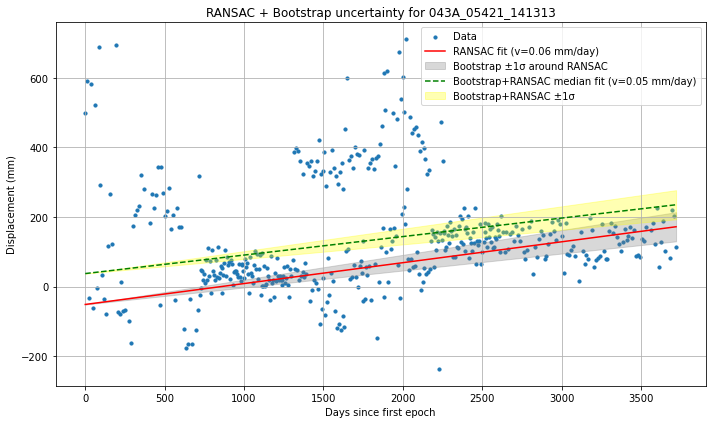

RANSAC velocity estimate: 0.0600 mm/day
Bootstrap standard deviation (uncertainty) on RANSAC velocity: 0.0113 mm/day


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.utils import resample
import daz_lib_licsar as dl

# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# 2. Convert epoch to numeric days
t0 = dazes['epoch'].min()
dazes['days'] = (dazes['epoch'] - t0).dt.days

X = dazes['days'].values.reshape(-1, 1)  # shape (n_samples, 1)
y = dazes['daz'].values

mask = ~np.isnan(y)
X_valid = X[mask]
y_valid = y[mask]

# 3. RANSAC velocity estimation (following your get_vel_ransac logic)
mask = ~np.isnan(y)
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
else:
    reg = RANSACRegressor().fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_


# 4. Bootstrap: Resample + RANSAC each time
n_boot = 100
boot_slopes = []

for _ in range(n_boot):
    idx = resample(np.arange(len(X_valid)))  # bootstrap resampling indices
    X_sample = X_valid[idx]
    y_sample = y_valid[idx]
    try:
        ransac = RANSACRegressor().fit(X_sample, y_sample)
        boot_slopes.append(ransac.estimator_.coef_[0])
    except:
        boot_slopes.append(np.nan)

boot_slopes = np.array(boot_slopes)
vel_boot = np.nanmedian(boot_slopes)   # Bootstrap median velocity
vstd_boot = np.nanstd(boot_slopes)      # Bootstrap standard deviation

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
xx = np.linspace(X_valid.min(), X_valid.max(), 100)

# Plot RANSAC line
plt.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC fit (v={vel_ransac:.2f} mm/day)')

# Bootstrap ±1σ uncertainty region (centered at vel_ransac)
plt.fill_between(xx, 
                 (vel_ransac - vstd_boot) * xx + intercept_ransac, 
                 (vel_ransac + vstd_boot) * xx + intercept_ransac,
                 color='gray', alpha=0.3, label='Bootstrap ±1σ around RANSAC')


plt.plot(xx, vel_boot * xx + intercept_boot, color='green', linestyle='--', label=f'Bootstrap+RANSAC median fit (v={vel_boot:.2f} mm/day)')

plt.fill_between(xx, 
                 (vel_boot - vstd_boot) * xx + intercept_boot,
                 (vel_boot + vstd_boot) * xx + intercept_boot,
                 color='yellow', alpha=0.3, label='Bootstrap+RANSAC ±1σ')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title(f"RANSAC + Bootstrap uncertainty for {frame}")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Print results
print(f"RANSAC velocity estimate: {vel_ransac:.4f} mm/day")
print(f"Bootstrap standard deviation (uncertainty) on RANSAC velocity: {vstd_boot:.4f} mm/day")


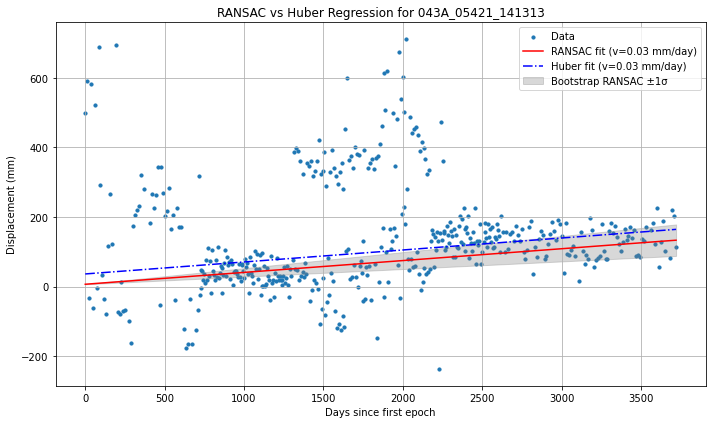

RANSAC velocity: 0.0340 mm/day
Huber velocity: 0.0344 mm/day
Bootstrap standard deviation on RANSAC velocity: 0.0122 mm/day


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, HuberRegressor
from sklearn.utils import resample
import daz_lib_licsar as dl

# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# 2. Convert epoch to numeric days
t0 = dazes['epoch'].min()
dazes['days'] = (dazes['epoch'] - t0).dt.days

X = dazes['days'].values.reshape(-1, 1)
y = dazes['daz'].values

# Remove NaNs
mask = ~np.isnan(y)
X_valid = X[mask]
y_valid = y[mask]

# 3. Fit RANSAC once
if len(X_valid) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
else:
    ransac_full = RANSACRegressor().fit(X_valid, y_valid)
    vel_ransac = ransac_full.estimator_.coef_[0]
    intercept_ransac = ransac_full.estimator_.intercept_

# 4. Fit Huber Regression
huber = HuberRegressor().fit(X_valid, y_valid)
vel_huber = huber.coef_[0]
intercept_huber = huber.intercept_

# 5. Bootstrap RANSAC to get uncertainty
n_boot = 100
boot_slopes = []

for _ in range(n_boot):
    idx = resample(np.arange(len(X_valid)))
    X_sample = X_valid[idx]
    y_sample = y_valid[idx]
    try:
        ransac = RANSACRegressor().fit(X_sample, y_sample)
        boot_slopes.append(ransac.estimator_.coef_[0])
    except:
        boot_slopes.append(np.nan)

boot_slopes = np.array(boot_slopes)
vstd_boot = np.nanstd(boot_slopes)  # Standard deviation of bootstrapped RANSAC velocities

# 6. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
xx = np.linspace(X_valid.min(), X_valid.max(), 100)

# RANSAC fit
plt.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC fit (v={vel_ransac:.2f} mm/day)')

# Huber fit
plt.plot(xx, vel_huber * xx + intercept_huber, color='blue', linestyle='-.', label=f'Huber fit (v={vel_huber:.2f} mm/day)')

# Bootstrap uncertainty region around RANSAC
plt.fill_between(xx, 
                 (vel_ransac - vstd_boot) * xx + intercept_ransac,
                 (vel_ransac + vstd_boot) * xx + intercept_ransac,
                 color='gray', alpha=0.3, label='Bootstrap RANSAC ±1σ')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title(f"RANSAC vs Huber Regression for {frame}")
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Print results
print(f"RANSAC velocity: {vel_ransac:.4f} mm/day")
print(f"Huber velocity: {vel_huber:.4f} mm/day")
print(f"Bootstrap standard deviation on RANSAC velocity: {vstd_boot:.4f} mm/day")


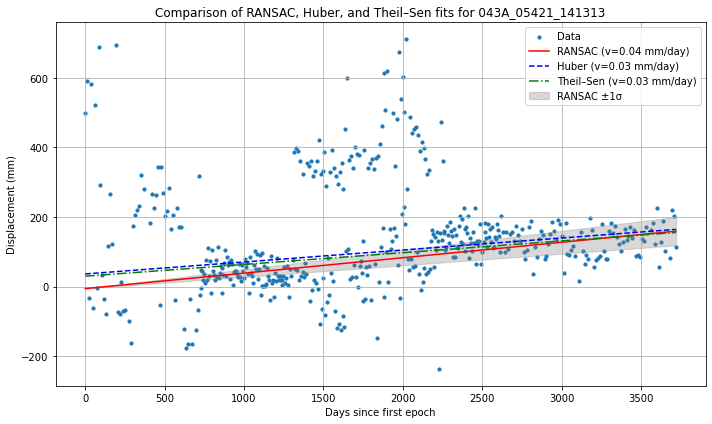

RANSAC velocity: 0.0443 mm/day
Huber velocity: 0.0344 mm/day
Theil–Sen velocity: 0.0338 mm/day
Bootstrap std. on RANSAC velocity: 0.0110 mm/day


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.utils import resample
import daz_lib_licsar as dl

# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# 2. Convert epoch to numeric days
t0 = dazes['epoch'].min()
dazes['days'] = (dazes['epoch'] - t0).dt.days

X = dazes['days'].values.reshape(-1, 1)
y = dazes['daz'].values

# Remove NaNs
mask = ~np.isnan(y)
X_valid = X[mask]
y_valid = y[mask]

# 3. Fit RANSAC
ransac = RANSACRegressor().fit(X_valid, y_valid)
vel_ransac = ransac.estimator_.coef_[0]
intercept_ransac = ransac.estimator_.intercept_

# 4. Fit Huber
huber = HuberRegressor().fit(X_valid, y_valid)
vel_huber = huber.coef_[0]
intercept_huber = huber.intercept_

# 5. Fit Theil–Sen
theilsen = TheilSenRegressor().fit(X_valid, y_valid)
vel_theilsen = theilsen.coef_[0]
intercept_theilsen = theilsen.intercept_

# 6. Bootstrap RANSAC to get uncertainty
n_boot = 100
boot_slopes = []

for _ in range(n_boot):
    idx = resample(np.arange(len(X_valid)))
    X_sample = X_valid[idx]
    y_sample = y_valid[idx]
    try:
        ransac_boot = RANSACRegressor().fit(X_sample, y_sample)
        boot_slopes.append(ransac_boot.estimator_.coef_[0])
    except:
        boot_slopes.append(np.nan)

boot_slopes = np.array(boot_slopes)
vstd_boot = np.nanstd(boot_slopes)  # standard deviation of bootstrapped RANSAC velocities

# 7. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
xx = np.linspace(X_valid.min(), X_valid.max(), 100)

# RANSAC fit
plt.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC (v={vel_ransac:.2f} mm/day)')

# Huber fit
plt.plot(xx, vel_huber * xx + intercept_huber, color='blue', linestyle='--', label=f'Huber (v={vel_huber:.2f} mm/day)')

# Theil–Sen fit
plt.plot(xx, vel_theilsen * xx + intercept_theilsen, color='green', linestyle='-.', label=f'Theil–Sen (v={vel_theilsen:.2f} mm/day)')

# Bootstrap uncertainty region around RANSAC
plt.fill_between(xx, 
                 (vel_ransac - vstd_boot) * xx + intercept_ransac,
                 (vel_ransac + vstd_boot) * xx + intercept_ransac,
                 color='gray', alpha=0.3, label='RANSAC ±1σ')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title(f"Comparison of RANSAC, Huber, and Theil–Sen fits for {frame}")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Print results
print(f"RANSAC velocity: {vel_ransac:.4f} mm/day")
print(f"Huber velocity: {vel_huber:.4f} mm/day")
print(f"Theil–Sen velocity: {vel_theilsen:.4f} mm/day")
print(f"Bootstrap std. on RANSAC velocity: {vstd_boot:.4f} mm/day")


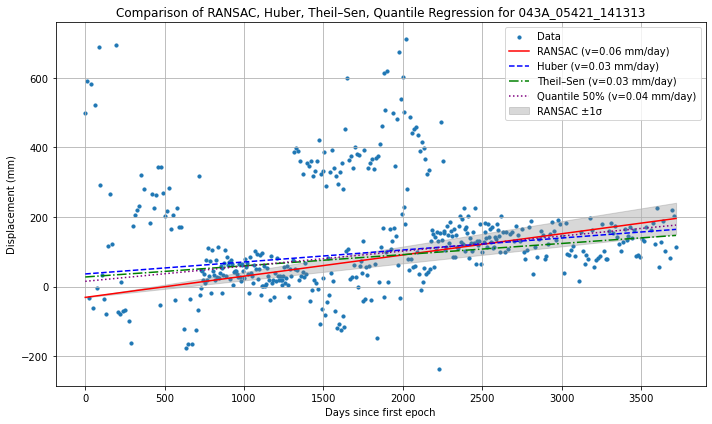

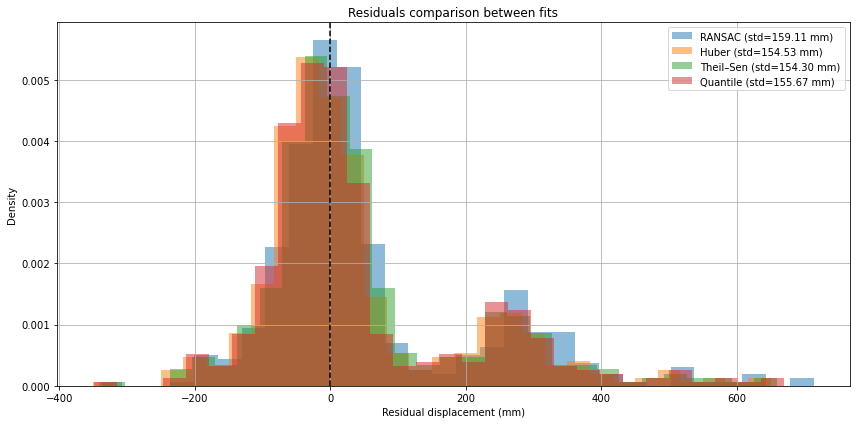

RANSAC velocity: 0.0609 mm/day
Huber velocity: 0.0344 mm/day
Theil–Sen velocity: 0.0321 mm/day
Quantile 50% velocity: 0.0434 mm/day
RANSAC residual std: 159.1098 mm
Huber residual std: 154.5290 mm
Theil–Sen residual std: 154.3048 mm
Quantile residual std: 155.6674 mm


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, HuberRegressor, TheilSenRegressor, QuantileRegressor
from sklearn.utils import resample
import daz_lib_licsar as dl

# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# 2. Convert epoch to numeric days
t0 = dazes['epoch'].min()
dazes['days'] = (dazes['epoch'] - t0).dt.days

X = dazes['days'].values.reshape(-1, 1)
y = dazes['daz'].values

# Remove NaNs
mask = ~np.isnan(y)
X_valid = X[mask]
y_valid = y[mask]

# 3. Fit RANSAC
ransac = RANSACRegressor().fit(X_valid, y_valid)
vel_ransac = ransac.estimator_.coef_[0]
intercept_ransac = ransac.estimator_.intercept_

# 4. Fit Huber
huber = HuberRegressor().fit(X_valid, y_valid)
vel_huber = huber.coef_[0]
intercept_huber = huber.intercept_

# 5. Fit Theil–Sen
theilsen = TheilSenRegressor().fit(X_valid, y_valid)
vel_theilsen = theilsen.coef_[0]
intercept_theilsen = theilsen.intercept_

# 6. Fit Quantile Regression (50% = median)
quantile = QuantileRegressor(quantile=0.5, solver='highs').fit(X_valid, y_valid)
vel_quantile = quantile.coef_[0]
intercept_quantile = quantile.intercept_

# 7. Bootstrap RANSAC to get uncertainty
n_boot = 100
boot_slopes = []

for _ in range(n_boot):
    idx = resample(np.arange(len(X_valid)))
    X_sample = X_valid[idx]
    y_sample = y_valid[idx]
    try:
        ransac_boot = RANSACRegressor().fit(X_sample, y_sample)
        boot_slopes.append(ransac_boot.estimator_.coef_[0])
    except:
        boot_slopes.append(np.nan)

boot_slopes = np.array(boot_slopes)
vstd_boot = np.nanstd(boot_slopes)  # standard deviation of bootstrapped RANSAC velocities

# 8. Plot fits
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
xx = np.linspace(X_valid.min(), X_valid.max(), 100)

# RANSAC fit
plt.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC (v={vel_ransac:.2f} mm/day)')

# Huber fit
plt.plot(xx, vel_huber * xx + intercept_huber, color='blue', linestyle='--', label=f'Huber (v={vel_huber:.2f} mm/day)')

# Theil–Sen fit
plt.plot(xx, vel_theilsen * xx + intercept_theilsen, color='green', linestyle='-.', label=f'Theil–Sen (v={vel_theilsen:.2f} mm/day)')

# Quantile Regression fit
plt.plot(xx, vel_quantile * xx + intercept_quantile, color='purple', linestyle=':', label=f'Quantile 50% (v={vel_quantile:.2f} mm/day)')

# Bootstrap uncertainty region around RANSAC
plt.fill_between(xx, 
                 (vel_ransac - vstd_boot) * xx + intercept_ransac,
                 (vel_ransac + vstd_boot) * xx + intercept_ransac,
                 color='gray', alpha=0.3, label='RANSAC ±1σ')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title(f"Comparison of RANSAC, Huber, Theil–Sen, Quantile Regression for {frame}")
plt.grid(True)
plt.tight_layout()
plt.show()

# 9. Compute residuals
residuals = {
    'RANSAC': y_valid.flatten() - (vel_ransac * X_valid.flatten() + intercept_ransac),
    'Huber': y_valid.flatten() - (vel_huber * X_valid.flatten() + intercept_huber),
    'Theil–Sen': y_valid.flatten() - (vel_theilsen * X_valid.flatten() + intercept_theilsen),
    'Quantile': y_valid.flatten() - (vel_quantile * X_valid.flatten() + intercept_quantile),
}

# 10. Plot residuals
plt.figure(figsize=(12, 6))
for name, res in residuals.items():
    plt.hist(res, bins=30, alpha=0.5, label=f'{name} (std={np.nanstd(res):.2f} mm)', density=True)

plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Residual displacement (mm)")
plt.ylabel("Density")
plt.title("Residuals comparison between fits")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 11. Print results
print(f"RANSAC velocity: {vel_ransac:.4f} mm/day")
print(f"Huber velocity: {vel_huber:.4f} mm/day")
print(f"Theil–Sen velocity: {vel_theilsen:.4f} mm/day")
print(f"Quantile 50% velocity: {vel_quantile:.4f} mm/day")


# Residual standard deviations
for name, res in residuals.items():
    print(f"{name} residual std: {np.nanstd(res):.4f} mm")


In [29]:
# Load frames_TR from file
homedir = '/home/users/mnergiz'
frames_file = os.path.join(homedir, 'frames_TR')

frames_TR = []
with open(frames_file, 'r') as f:
    for line in f:
        frames_TR.append(line.strip())

# Prepare subplots
n = len(frames_TR)

Frame 116A_04978_131311 failed: tuple index out of range


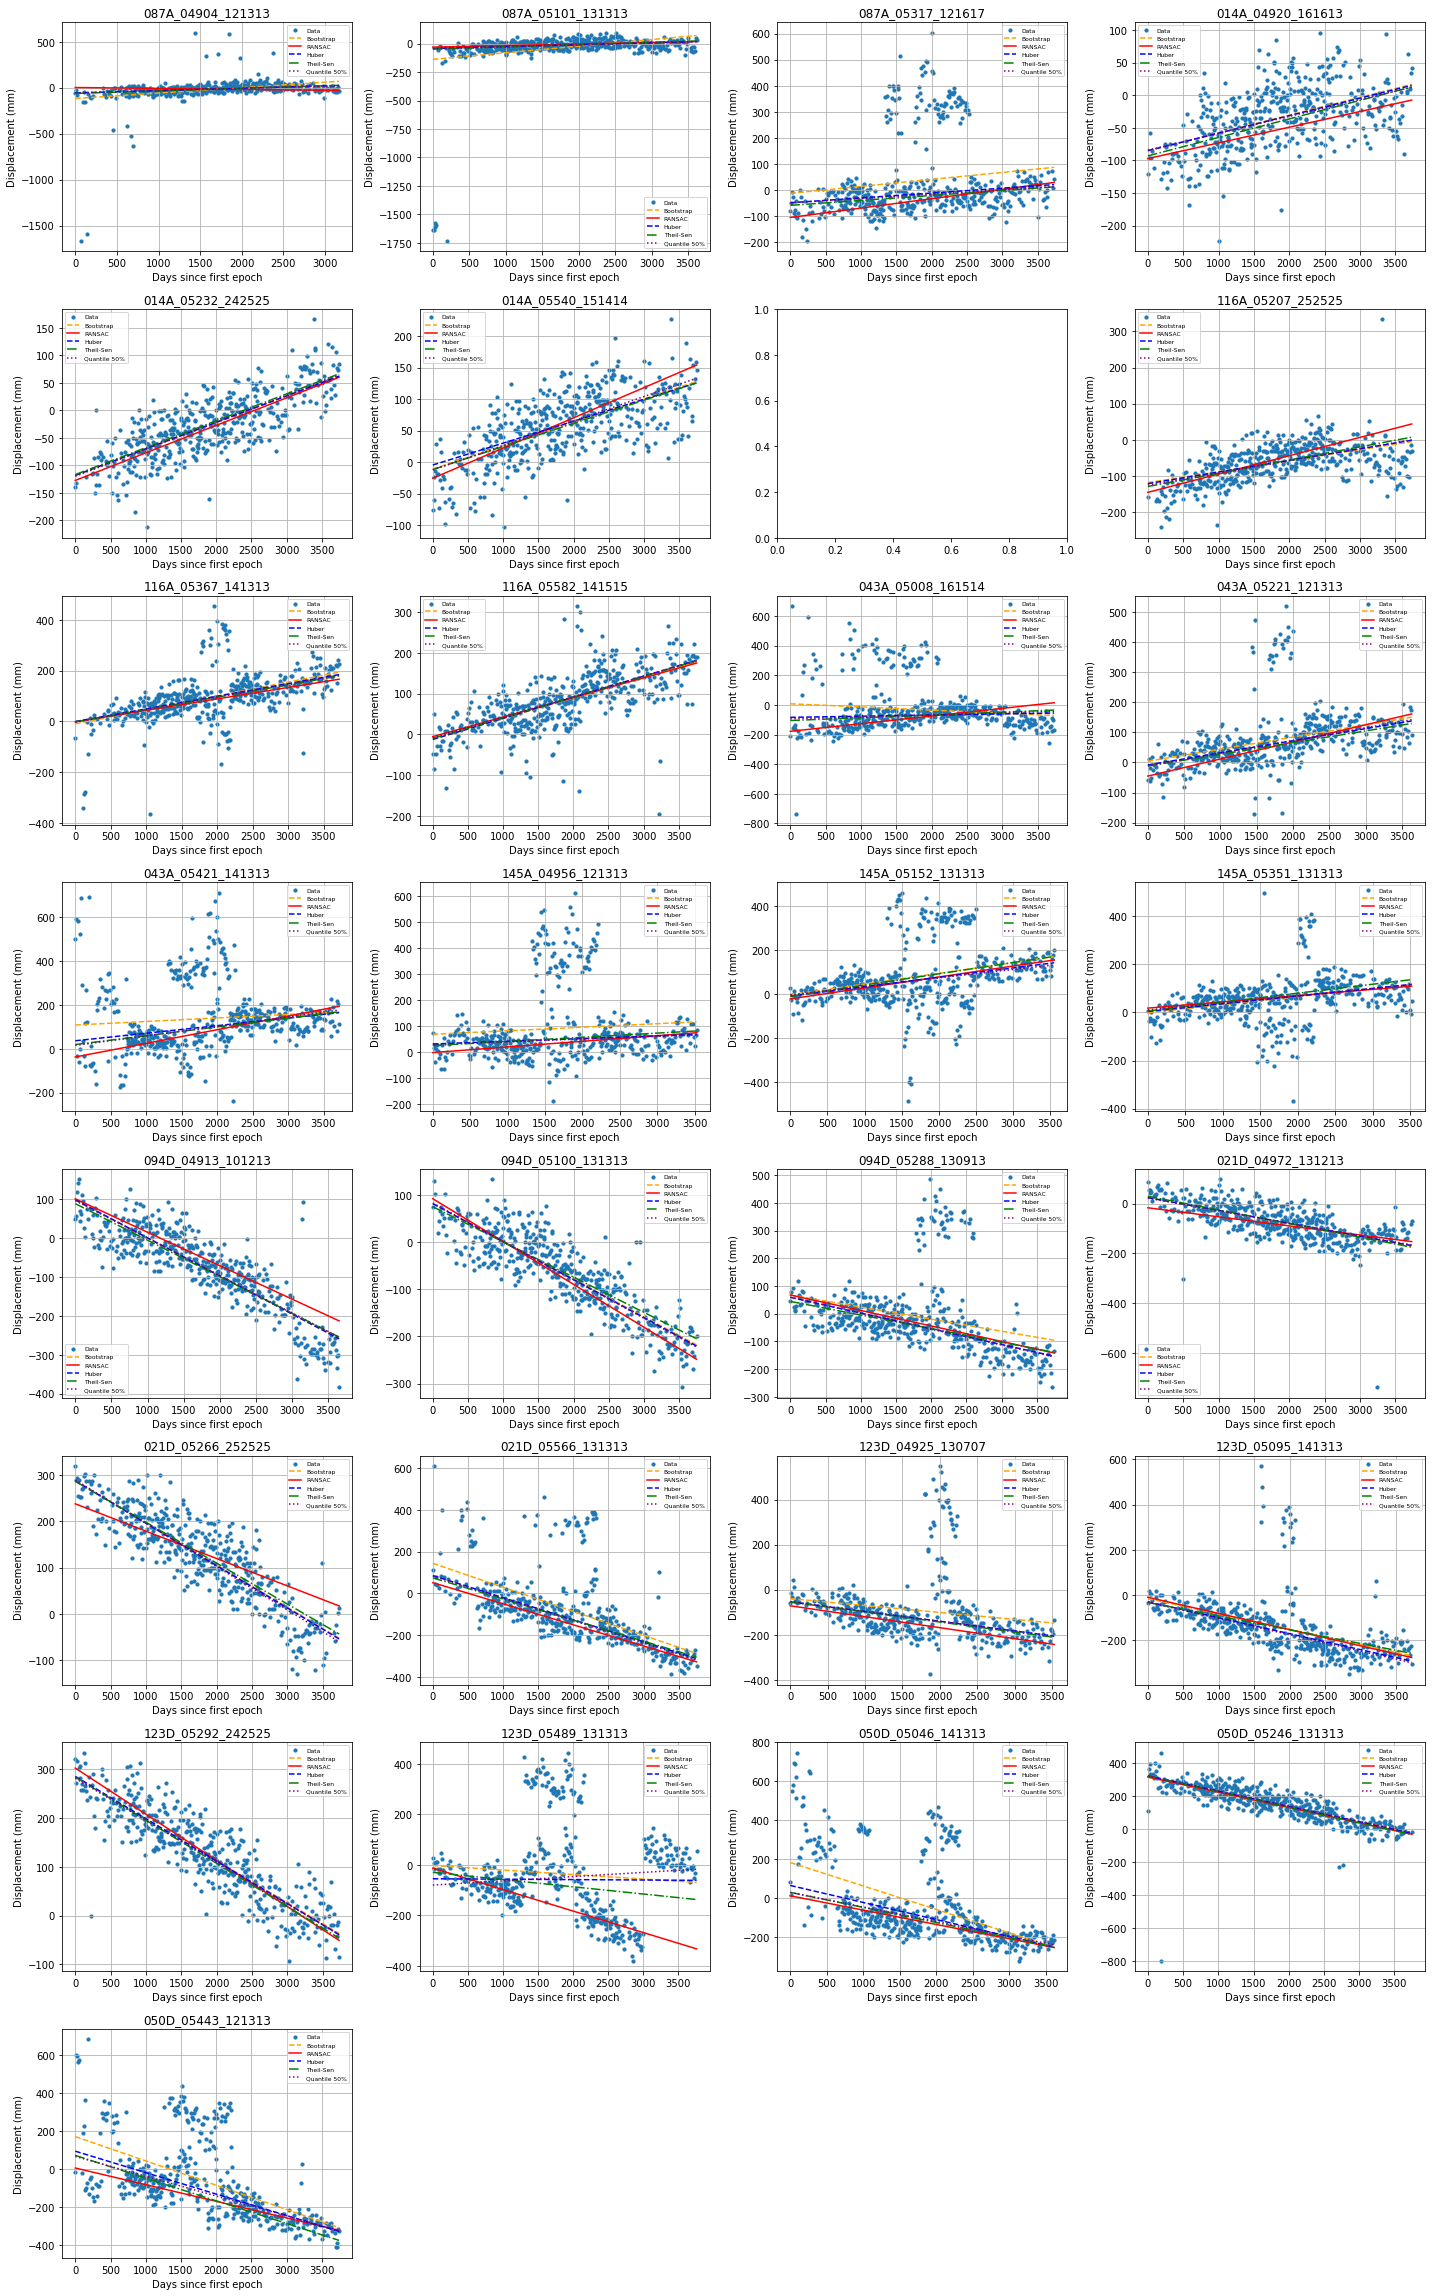

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, HuberRegressor, TheilSenRegressor, QuantileRegressor
from sklearn.utils import resample
import os
import daz_lib_licsar as dl

# Load frames_TR from file
homedir = '/home/users/mnergiz'
frames_file = os.path.join(homedir, 'frames_TR')

frames_TR = []
with open(frames_file, 'r') as f:
    for line in f:
        frames_TR.append(line.strip())

# Prepare subplots
n = len(frames_TR)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Loop through frames
for idx, frame in enumerate(frames_TR):
    try:
        dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
        dazes['epoch'] = pd.to_datetime(dazes['epoch'])
        dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

        t0 = dazes['epoch'].min()
        dazes['days'] = (dazes['epoch'] - t0).dt.days

        X = dazes['days'].values.reshape(-1, 1)
        y = dazes['daz'].values

        mask = ~np.isnan(y)
        X_valid = X[mask]
        y_valid = y[mask]

        if len(X_valid) < 2:
            continue  # Skip if not enough points

        # Fit models
        ransac = RANSACRegressor().fit(X_valid, y_valid)
        huber = HuberRegressor().fit(X_valid, y_valid)
        theilsen = TheilSenRegressor().fit(X_valid, y_valid)
        quantile = QuantileRegressor(quantile=0.5, solver='highs').fit(X_valid, y_valid)

        vel_ransac, intercept_ransac = ransac.estimator_.coef_[0], ransac.estimator_.intercept_
        vel_huber, intercept_huber = huber.coef_[0], huber.intercept_
        vel_theilsen, intercept_theilsen = theilsen.coef_[0], theilsen.intercept_
        vel_quantile, intercept_quantile = quantile.coef_[0], quantile.intercept_

        # 4. Bootstrap
        boot_slopes = []
        n_boot = 100
        
        for _ in range(n_boot):
            idx_boot = resample(np.arange(len(X_valid)))  # <= renamed here
            X_sample = X_valid[idx_boot]
            y_sample = y_valid[idx_boot]
            try:
                reg = LinearRegression().fit(X_sample, y_sample)
                boot_slopes.append(reg.coef_[0])
            except:
                boot_slopes.append(np.nan)
        
        boot_slopes = np.array(boot_slopes)
        vstd_boot = np.nanstd(boot_slopes)
        vel_boot = np.nanmedian(boot_slopes)


        # # 4. Bootstrap: Resample + RANSAC each time
        # n_boot = 100
        # boot_slopes = []
        
        # for _ in range(n_boot):
        #     idx = resample(np.arange(len(X_valid)))  # bootstrap resampling indices
        #     X_sample = X_valid[idx]
        #     y_sample = y_valid[idx]
        #     try:
        #         ransac = RANSACRegressor().fit(X_sample, y_sample)
        #         boot_slopes.append(ransac.estimator_.coef_[0])
        #     except:
        #         boot_slopes.append(np.nan)
        
        # boot_slopes = np.array(boot_slopes)
        # vel_boot = np.nanmedian(boot_slopes)   # Bootstrap median velocity
        # vstd_boot = np.nanstd(boot_slopes)      # Bootstrap standard deviation
        

        # Plot fits
        ax = axes[idx]
        ax.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
        xx = np.linspace(X_valid.min(), X_valid.max(), 100)

        ax.plot(xx, vel_boot * xx + (np.nanmean(y_valid) - vel_boot * np.nanmean(X_valid)), color='orange', linestyle='--', label=f'Bootstrap')
        ax.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label='RANSAC')
        ax.plot(xx, vel_huber * xx + intercept_huber, color='blue', linestyle='--', label='Huber')
        ax.plot(xx, vel_theilsen * xx + intercept_theilsen, color='green', linestyle='-.', label='Theil-Sen')
        ax.plot(xx, vel_quantile * xx + intercept_quantile, color='purple', linestyle=':', label='Quantile 50%')

        # ax.fill_between(xx,
        #                 (vel_ransac - vstd_boot) * xx + intercept_ransac,
        #                 (vel_ransac + vstd_boot) * xx + intercept_ransac,
        #                 color='gray', alpha=0.3)

        ax.set_title(frame)
        ax.set_xlabel("Days since first epoch")
        ax.set_ylabel("Displacement (mm)")
        ax.grid(True)
        ax.legend(fontsize=6)

    except Exception as e:
        print(f"Frame {frame} failed: {e}")

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

Residuals calc failed for 116A_04978_131311: tuple index out of range


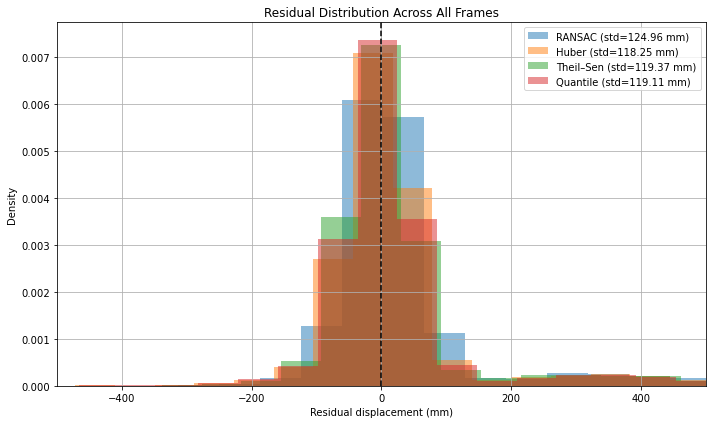

In [39]:
# --- Collect residuals across all frames ---
all_residuals = {
    'RANSAC': [],
    'Huber': [],
    'Theil–Sen': [],
    'Quantile': [],
}

# Second pass to recompute residuals for stacking
for frame in frames_TR:
    try:
        dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
        dazes['epoch'] = pd.to_datetime(dazes['epoch'])
        dazes['daz'] = dazes['daz'] * 14000  # Convert to mm
        t0 = dazes['epoch'].min()
        dazes['days'] = (dazes['epoch'] - t0).dt.days

        X = dazes['days'].values.reshape(-1, 1)
        y = dazes['daz'].values
        mask = ~np.isnan(y)
        X_valid = X[mask]
        y_valid = y[mask]
        if len(X_valid) < 2:
            continue

        # Fit again
        ransac = RANSACRegressor().fit(X_valid, y_valid)
        huber = HuberRegressor().fit(X_valid, y_valid)
        theilsen = TheilSenRegressor().fit(X_valid, y_valid)
        quantile = QuantileRegressor(quantile=0.5, solver='highs').fit(X_valid, y_valid)

        all_residuals['RANSAC'].extend(
            y_valid.flatten() - (ransac.estimator_.coef_[0] * X_valid.flatten() + ransac.estimator_.intercept_)
        )
        all_residuals['Huber'].extend(
            y_valid.flatten() - (huber.coef_[0] * X_valid.flatten() + huber.intercept_)
        )
        all_residuals['Theil–Sen'].extend(
            y_valid.flatten() - (theilsen.coef_[0] * X_valid.flatten() + theilsen.intercept_)
        )
        all_residuals['Quantile'].extend(
            y_valid.flatten() - (quantile.coef_[0] * X_valid.flatten() + quantile.intercept_)
        )

    except Exception as e:
        print(f"Residuals calc failed for {frame}: {e}")

# --- Plot combined residuals histogram ---
plt.figure(figsize=(10, 6))
for name, res in all_residuals.items():
    res = np.array(res)
    plt.hist(res, bins=40, alpha=0.5, label=f'{name} (std={np.nanstd(res):.2f} mm)', density=True)

plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Residual displacement (mm)')
plt.ylabel('Density')
plt.xlim(-500,500)
plt.title('Residual Distribution Across All Frames')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
from scipy.stats import skew, kurtosis

# Initialize table
stats_summary = []

for name, res in all_residuals.items():
    res = np.array(res)
    mean = np.nanmean(res)
    median = np.nanmedian(res)
    std = np.nanstd(res)
    skewness = skew(res, nan_policy='omit')
    kurt = kurtosis(res, nan_policy='omit')
    mae = np.nanmean(np.abs(res))
    rmse = np.sqrt(np.nanmean(res**2))
    
    stats_summary.append([name, mean, median, std, skewness, kurt, mae, rmse])

# Make into a dataframe
stats_df = pd.DataFrame(stats_summary, columns=['Method', 'Mean (mm)', 'Median (mm)', 'Std (mm)', 'Skewness', 'Kurtosis', 'MAE (mm)', 'RMSE (mm)'])

# Show
print(stats_df)


      Method  Mean (mm)  Median (mm)    Std (mm)  Skewness   Kurtosis  \
0     RANSAC  26.434082     5.917787  123.040945  0.311842  27.130980   
1      Huber  15.224679    -0.850755  118.254249  0.129517  28.416802   
2  Theil–Sen  16.509679    -1.089739  119.225639  0.231412  27.666169   
3   Quantile  16.600933     0.000000  119.110900  0.184824  27.926172   

    MAE (mm)   RMSE (mm)  
0  66.198672  125.848460  
1  64.035135  119.230275  
2  64.642058  120.363294  
3  63.892947  120.262203  


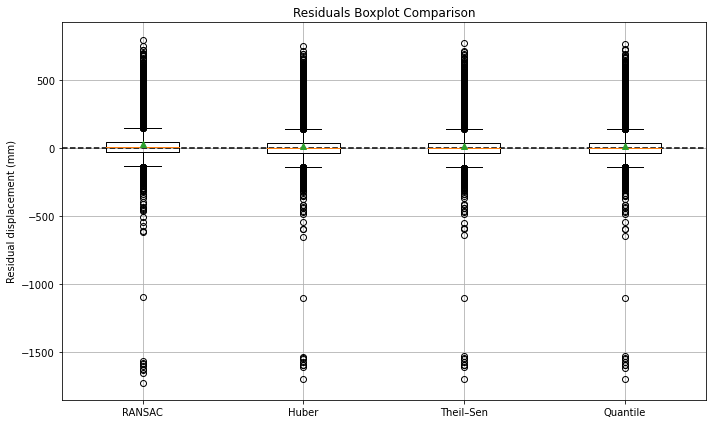

In [36]:
plt.figure(figsize=(10,6))
plt.boxplot([np.array(all_residuals[name]) for name in all_residuals.keys()], labels=all_residuals.keys(), showmeans=True)
plt.axhline(0, color='k', linestyle='--')
plt.ylabel('Residual displacement (mm)')
plt.title('Residuals Boxplot Comparison')
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.utils import resample
import daz_lib_licsar as dl

# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# 2. Convert epoch to numeric days
t0 = dazes['epoch'].min()
dazes['days'] = (dazes['epoch'] - t0).dt.days

X = dazes['days'].values.reshape(-1, 1)  # shape (n_samples, 1)
y = dazes['daz'].values

mask = ~np.isnan(y)
X_valid = X[mask]
y_valid = y[mask]

# 3. RANSAC velocity estimation (following your get_vel_ransac logic)
mask = ~np.isnan(y)
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
else:
    reg = RANSACRegressor().fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_


# 7. Bootstrap RANSAC to get uncertainty
n_boot = 100
boot_slopes = []

for _ in range(n_boot):
    idx = resample(np.arange(len(X_valid)))
    X_sample = X_valid[idx]
    y_sample = y_valid[idx]
    try:
        reg = RANSACRegressor(random_state=42).fit(X_sample, y_sample)
        boot_slopes.append(reg.estimator_.coef_[0])
    except:
        boot_slopes.append(np.nan)

boot_slopes = np.array(boot_slopes)
vstd_boot = np.nanstd(boot_slopes)
vel_boot = np.nanmedian(boot_slopes)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
xx = np.linspace(X_valid.min(), X_valid.max(), 100)

# RANSAC line
plt.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC fit (v={vel_ransac:.2f} mm/day)')

# Bootstrap uncertainty region around RANSAC
plt.fill_between(xx, 
                 (vel_ransac - vstd_boot) * xx + intercept_ransac,
                 (vel_ransac + vstd_boot) * xx + intercept_ransac,
                 color='gray', alpha=0.3, label='RANSAC ±1σ')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title("RANSAC and Bootstrap Fits to DAZ Displacement")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Print numbers
print(f"RANSAC velocity estimate: {vel_ransac:.4f} mm/day")


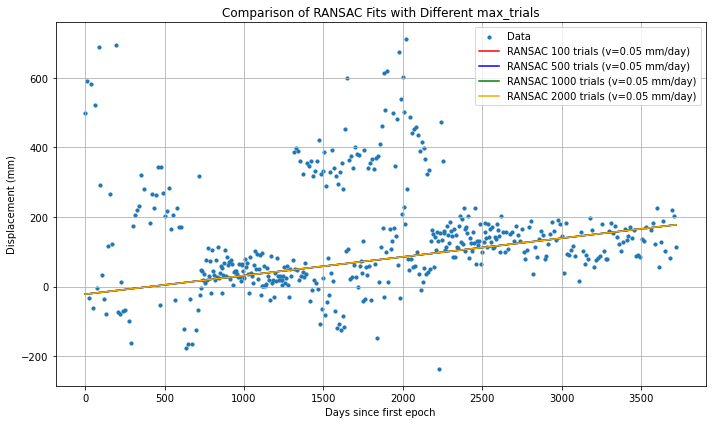

In [51]:
# 5. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')

xx = np.linspace(X_valid.min(), X_valid.max(), 100)

colors = ['red', 'blue', 'green', 'orange']
for i, max_trials in enumerate(max_trials_list):
    vel, intercept = ransac_results[max_trials]
    plt.plot(xx, vel * xx + intercept, color=colors[i], label=f'RANSAC {max_trials} trials (v={vel:.2f} mm/day)')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title("Comparison of RANSAC Fits with Different max_trials")
plt.grid(True)
plt.tight_layout()
plt.show()


In [52]:
# 3. Try RANSAC with different residual_threshold
residual_threshold_list = [5, 10, 20, 50]  # mm
ransac_results = {}

for residual_threshold in residual_threshold_list:
    if np.sum(mask) < 2:
        vel_ransac = np.nan
        intercept_ransac = np.nan
    else:
        reg = RANSACRegressor(
            residual_threshold=residual_threshold,
            max_trials=1000,  # safe value
            random_state=42
        ).fit(X_valid, y_valid)
        vel_ransac = reg.estimator_.coef_[0]
        intercept_ransac = reg.estimator_.intercept_
    
    ransac_results[residual_threshold] = (vel_ransac, intercept_ransac)

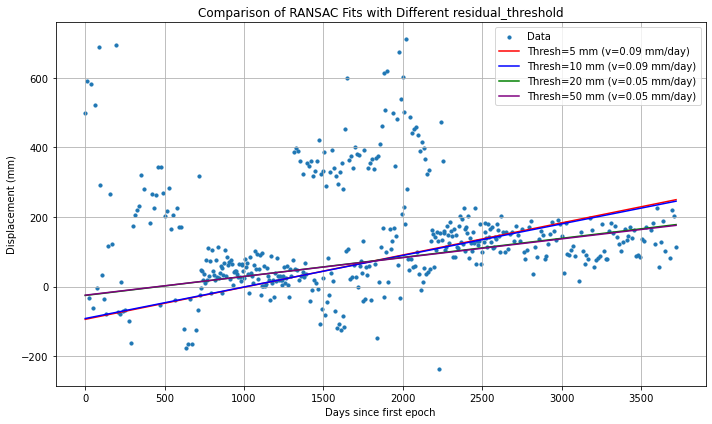

In [53]:
# 5. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')

xx = np.linspace(X_valid.min(), X_valid.max(), 100)

colors = ['red', 'blue', 'green', 'purple']
for i, residual_threshold in enumerate(residual_threshold_list):
    vel, intercept = ransac_results[residual_threshold]
    plt.plot(xx, vel * xx + intercept, color=colors[i], label=f'Thresh={residual_threshold} mm (v={vel:.2f} mm/day)')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title("Comparison of RANSAC Fits with Different residual_threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


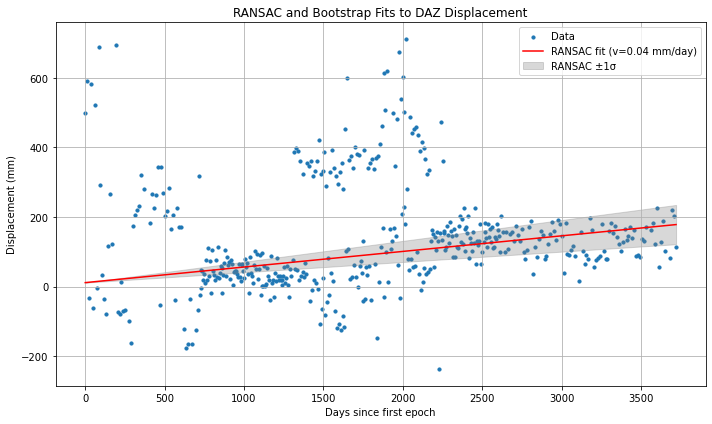

RANSAC velocity estimate: 0.0448 mm/day


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.utils import resample
import daz_lib_licsar as dl

# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# 2. Convert epoch to numeric days
t0 = dazes['epoch'].min()
dazes['days'] = (dazes['epoch'] - t0).dt.days

X = dazes['days'].values.reshape(-1, 1)  # shape (n_samples, 1)
y = dazes['daz'].values

mask = ~np.isnan(y)
X_valid = X[mask]
y_valid = y[mask]

# 3. RANSAC velocity estimation (following your get_vel_ransac logic)
mask = ~np.isnan(y)
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
else:
    reg = RANSACRegressor().fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_


# 7. Bootstrap RANSAC to get uncertainty
n_boot = 100
boot_slopes = []

for _ in range(n_boot):
    idx = resample(np.arange(len(X_valid)))
    X_sample = X_valid[idx]
    y_sample = y_valid[idx]
    try:
        reg = RANSACRegressor(random_state=42).fit(X_sample, y_sample)
        boot_slopes.append(reg.estimator_.coef_[0])
    except:
        boot_slopes.append(np.nan)

boot_slopes = np.array(boot_slopes)
vstd_boot = np.nanstd(boot_slopes)
vel_boot = np.nanmedian(boot_slopes)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
xx = np.linspace(X_valid.min(), X_valid.max(), 100)

# RANSAC line
plt.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC fit (v={vel_ransac:.2f} mm/day)')

# Bootstrap uncertainty region around RANSAC
plt.fill_between(xx, 
                 (vel_ransac - vstd_boot) * xx + intercept_ransac,
                 (vel_ransac + vstd_boot) * xx + intercept_ransac,
                 color='gray', alpha=0.3, label='RANSAC ±1σ')

plt.legend()
plt.xlabel("Days since first epoch")
plt.ylabel("Displacement (mm)")
plt.title("RANSAC and Bootstrap Fits to DAZ Displacement")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Print numbers
print(f"RANSAC velocity estimate: {vel_ransac:.4f} mm/day")


087A_04904_121313: RANSAC velocity = 0.0095 mm/day, vstd = 0.0176 mm/day
087A_05101_131313: RANSAC velocity = 0.0120 mm/day, vstd = 0.0110 mm/day
087A_05317_121617: RANSAC velocity = 0.0209 mm/day, vstd = 0.0119 mm/day
014A_04920_161613: RANSAC velocity = 0.0139 mm/day, vstd = 0.0114 mm/day
014A_05232_242525: RANSAC velocity = 0.0418 mm/day, vstd = 0.0086 mm/day
014A_05540_151414: RANSAC velocity = 0.0610 mm/day, vstd = 0.0095 mm/day
Frame 116A_04978_131311 failed: tuple index out of range
116A_05207_252525: RANSAC velocity = 0.0393 mm/day, vstd = 0.0163 mm/day
116A_05367_141313: RANSAC velocity = 0.0394 mm/day, vstd = 0.0093 mm/day
116A_05582_141515: RANSAC velocity = 0.0331 mm/day, vstd = 0.0099 mm/day
043A_05008_161514: RANSAC velocity = 0.0341 mm/day, vstd = 0.0201 mm/day
043A_05221_121313: RANSAC velocity = 0.0397 mm/day, vstd = 0.0120 mm/day
043A_05421_141313: RANSAC velocity = 0.0536 mm/day, vstd = 0.0134 mm/day
145A_04956_121313: RANSAC velocity = 0.0040 mm/day, vstd = 0.0096 m

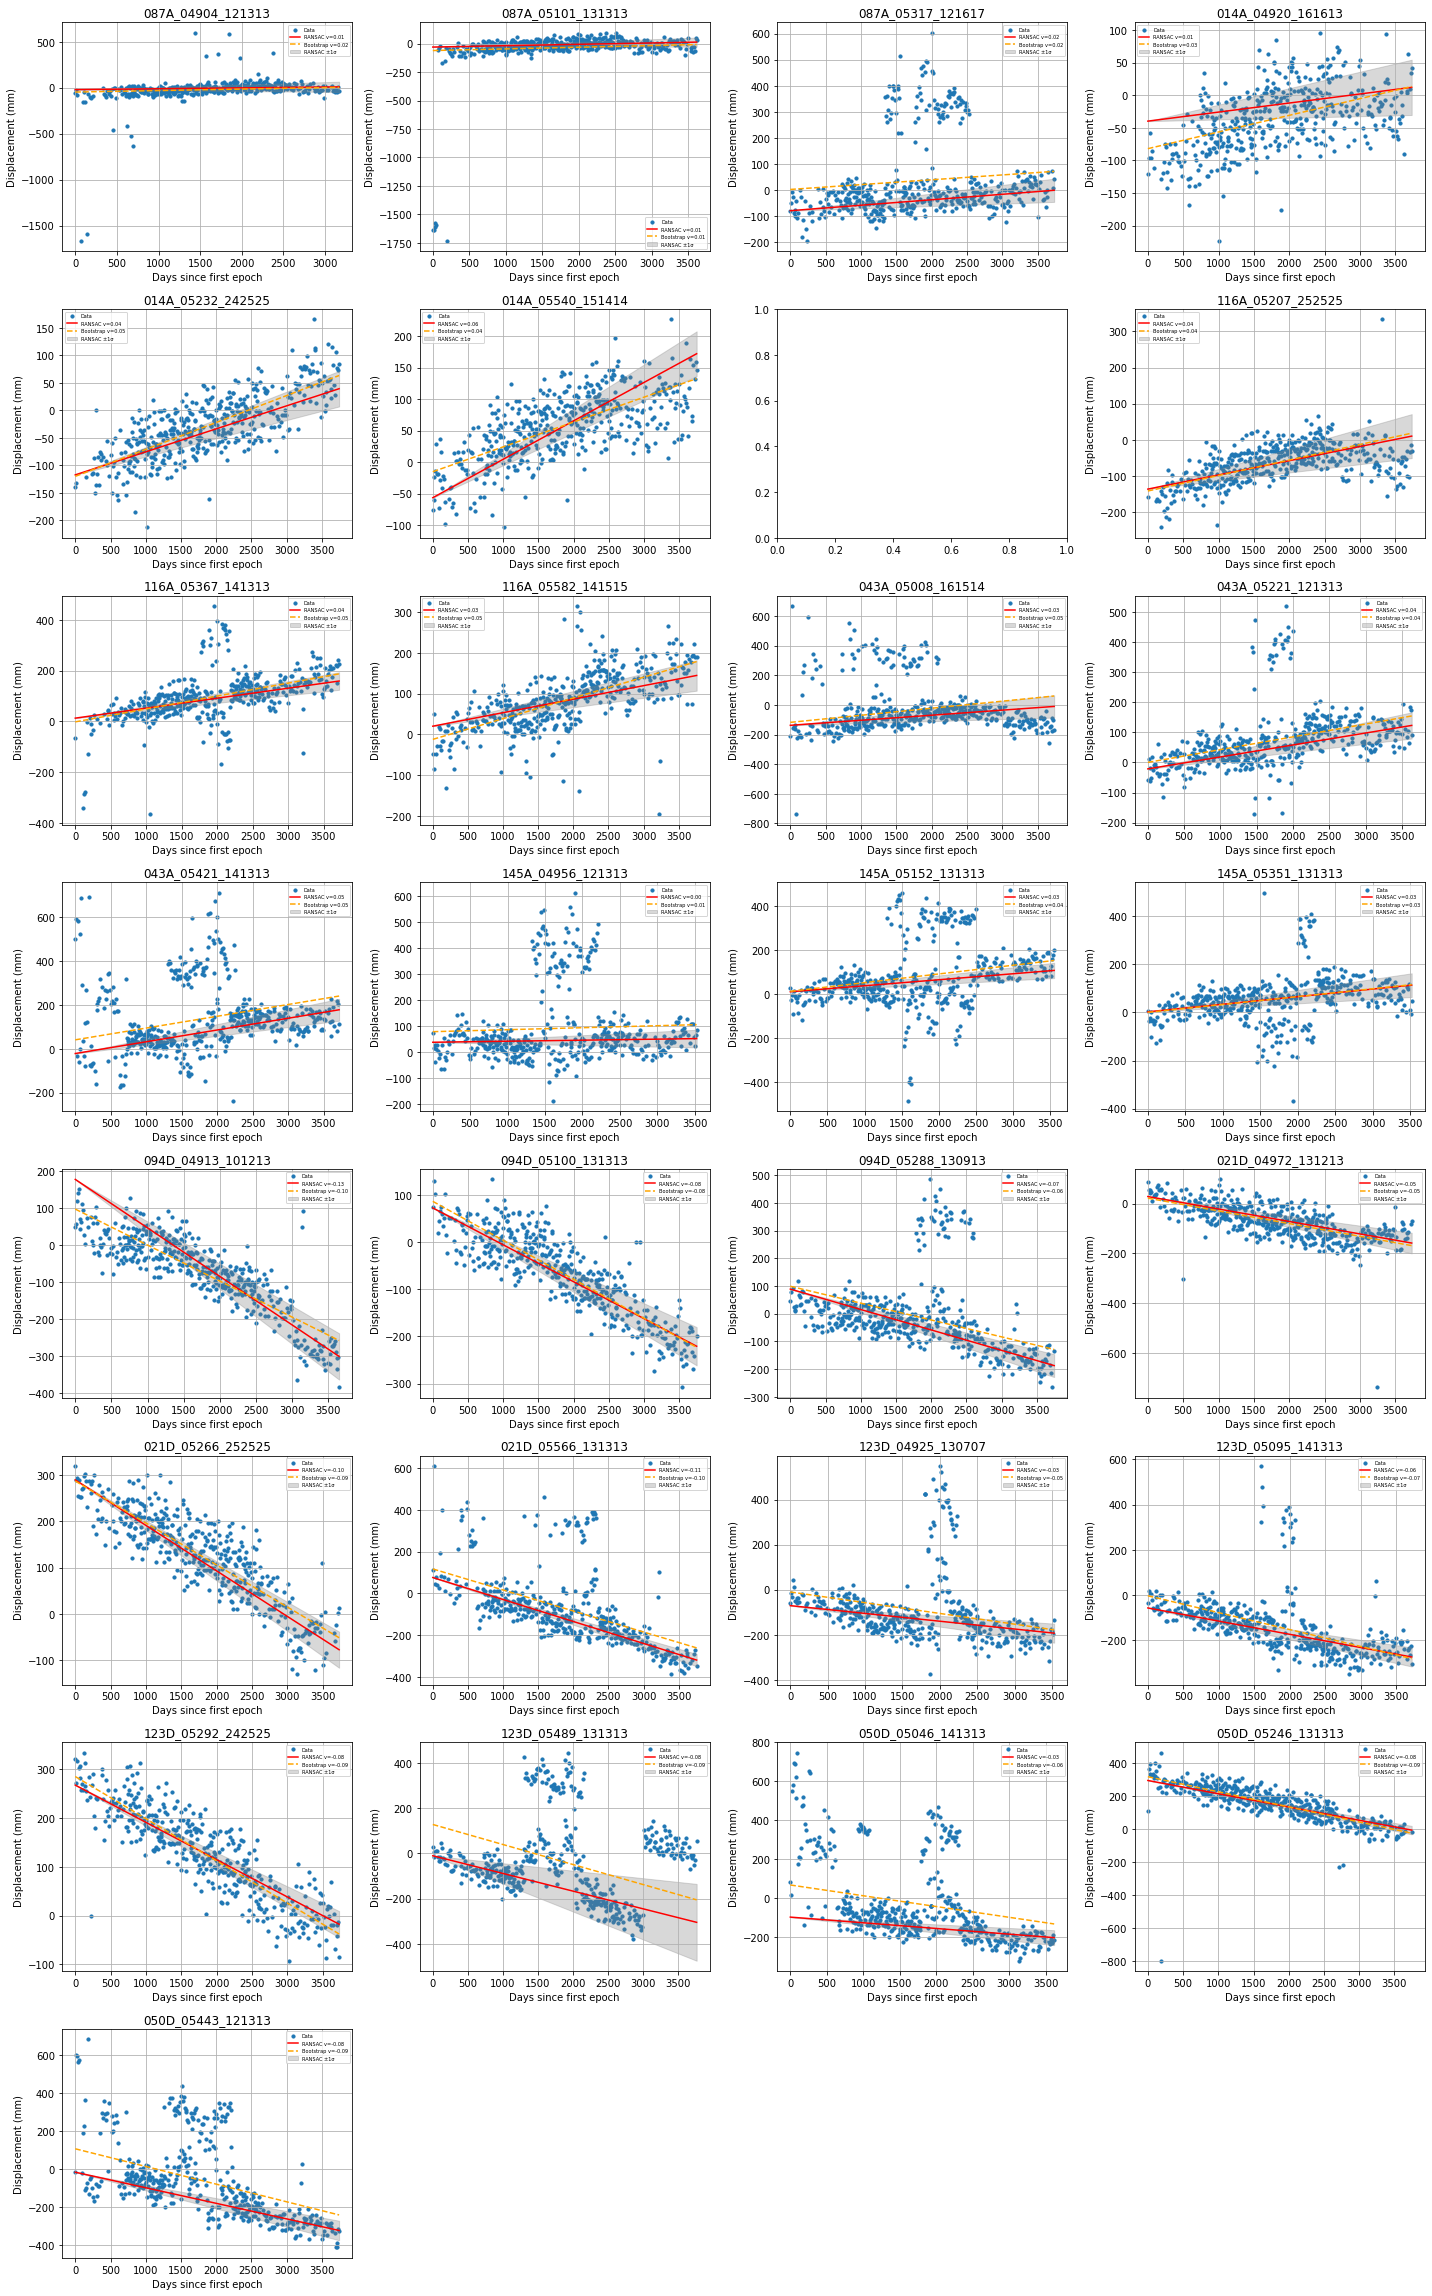

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.utils import resample
import os
import daz_lib_licsar as dl

# Load frames_TR from file
homedir = '/home/users/mnergiz'
frames_file = os.path.join(homedir, 'frames_TR')

frames_TR = []
with open(frames_file, 'r') as f:
    for line in f:
        frames_TR.append(line.strip())

# Prepare subplots
n = len(frames_TR)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Loop through frames
for idx, frame in enumerate(frames_TR):
    try:
        dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
        dazes['epoch'] = pd.to_datetime(dazes['epoch'])
        dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

        t0 = dazes['epoch'].min()
        dazes['days'] = (dazes['epoch'] - t0).dt.days

        X = dazes['days'].values.reshape(-1, 1)
        y = dazes['daz'].values

        mask = ~np.isnan(y)
        X_valid = X[mask]
        y_valid = y[mask]

        if len(X_valid) < 2:
            continue  # Skip if not enough valid points

        # 3. RANSAC velocity estimation
        reg = RANSACRegressor(random_state=42).fit(X_valid, y_valid)
        vel_ransac = reg.estimator_.coef_[0]
        intercept_ransac = reg.estimator_.intercept_

        # 4. Bootstrap RANSAC to get uncertainty
        n_boot = 100
        boot_slopes = []

        for _ in range(n_boot):
            idx_boot = resample(np.arange(len(X_valid)))
            X_sample = X_valid[idx_boot]
            y_sample = y_valid[idx_boot]
            try:
                reg_boot = RANSACRegressor(random_state=42).fit(X_sample, y_sample)
                boot_slopes.append(reg_boot.estimator_.coef_[0])
            except:
                boot_slopes.append(np.nan)

        boot_slopes = np.array(boot_slopes)
        vstd_boot = np.nanstd(boot_slopes)
        vel_boot = np.nanmedian(boot_slopes)

        # 5. Plot
        ax = axes[idx]
        ax.scatter(X_valid.flatten(), y_valid, s=10, label='Data')
        xx = np.linspace(X_valid.min(), X_valid.max(), 100)

        ax.plot(xx, vel_ransac * xx + intercept_ransac, color='red', label=f'RANSAC v={vel_ransac:.2f}')
        
        intercept_boot = np.nanmean(y_valid) - vel_boot * np.nanmean(X_valid)
        ax.plot(xx, vel_boot * xx + intercept_boot, color='orange', linestyle='--', label=f'Bootstrap v={vel_boot:.2f}')

        ax.fill_between(xx,
                        (vel_ransac - vstd_boot) * xx + intercept_ransac,
                        (vel_ransac + vstd_boot) * xx + intercept_ransac,
                        color='gray', alpha=0.3, label='RANSAC ±1σ')

        ax.set_title(frame)
        ax.set_xlabel("Days since first epoch")
        ax.set_ylabel("Displacement (mm)")
        ax.grid(True)
        ax.legend(fontsize=5)

        print(f"{frame}: RANSAC velocity = {vel_ransac:.4f} mm/day, vstd = {vstd_boot:.4f} mm/day")

    except Exception as e:
        print(f"Frame {frame} failed: {e}")

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()
